In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Reading the data

In [2]:
project=pd.read_csv('/content/crimes.csv')

In [3]:
project.shape

(247988, 12)

In [5]:
project.head(3)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,221412410,2022-06-15,2020-11-12,1700,Pacific,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),0,NaN,NaN,NaN,Invest Cont,13600 MARINA POINT DR
1,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
2,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST


In [6]:
project.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247988 entries, 0 to 247987
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         247988 non-null  int64 
 1   Date Rptd     247988 non-null  object
 2   DATE OCC      247988 non-null  object
 3   TIME OCC      247988 non-null  int64 
 4   AREA NAME     247988 non-null  object
 5   Crm Cd Desc   247988 non-null  object
 6   Vict Age      247988 non-null  int64 
 7   Vict Sex      215740 non-null  object
 8   Vict Descent  215739 non-null  object
 9   Weapon Desc   80087 non-null   object
 10  Status Desc   247988 non-null  object
 11  LOCATION      247988 non-null  object
dtypes: int64(3), object(9)
memory usage: 22.7+ MB


In [7]:
project.isna().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,32248
Vict Descent,32249
Weapon Desc,167901


In [8]:
project.duplicated('DR_NO').sum()

np.int64(0)

Cleaning the data

In [9]:
project=project.drop_duplicates('DR_NO')

In [10]:
project=project.dropna(subset=['Status Desc','LOCATION'])

In [11]:
project.isna().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,32248
Vict Descent,32249
Weapon Desc,167901


In [32]:
project ['Vict Descent']= project['Vict Descent'].replace({
    'A': 'Other Asian',
    'B': 'Black',
    'C': 'Chinese',
    'D': 'Cambodian',
    'F': 'Filipino',
    'G': 'Guamanian',
    'H': 'Hispanic/Latin/Mexican',
    'I': 'American Indian/Alaskan Native',
    'J': 'Japanese',
    'K': 'Korean',
    'L': 'Laotian',
    'O': 'Other',
    'P': 'Pacific Islander',
    'S': 'Samoan',
    'U': 'Hawaiian',
    'V': 'Vietnamese',
    'W': 'White',
    'Z': 'Asian Indian',
    '-': 'Unknown',
    'X': 'Unknown',
})
project['Weapon Desc']=project['Weapon Desc'].fillna('Unknown')
project['Vict Sex']=project['Vict Sex'].fillna('Unknown')
project['Vict Descent'] = project['Vict Descent'].fillna('Unknown')

In [13]:
project.isna().sum()

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA NAME,0
Crm Cd Desc,0
Vict Age,0
Vict Sex,0
Vict Descent,0
Weapon Desc,0


In [14]:
project['Date Rptd']=pd.to_datetime (project['Date Rptd'])
project['DATE OCC']=pd.to_datetime (project['DATE OCC'])

In [15]:
project['TIME OCC']= project['TIME OCC'].astype(str).str.zfill(4)
project['TIME OCC']= project['TIME OCC'].astype(int)
project ['HOUR OCC']= project['TIME OCC']//100

In [16]:
project.head(3)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION,HOUR OCC
0,221412410,2022-06-15,2020-11-12,1700,Pacific,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),0,Unknown,Unknown,Unknown,Invest Cont,13600 MARINA POINT DR,17
1,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,Unknown,Invest Cont,2500 S SYCAMORE AV,11
2,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,Unknown,Invest Cont,3300 SAN MARINO ST,16


In [17]:
project ['Vict Sex']= project['Vict Sex'].replace({
    'M':'Male',
    'F':'Female',
    'X':'Unknown',
    'H':'Unknown',
    '-':'Unknown'
})

Answering the questions

In [18]:
#Q1
peak_crime_hour=int(project['HOUR OCC'].mode()[0])
print(f'Peak Crime Hour is {peak_crime_hour}:00 (Noon)')

Peak Crime Hour is 12:00 (Noon)


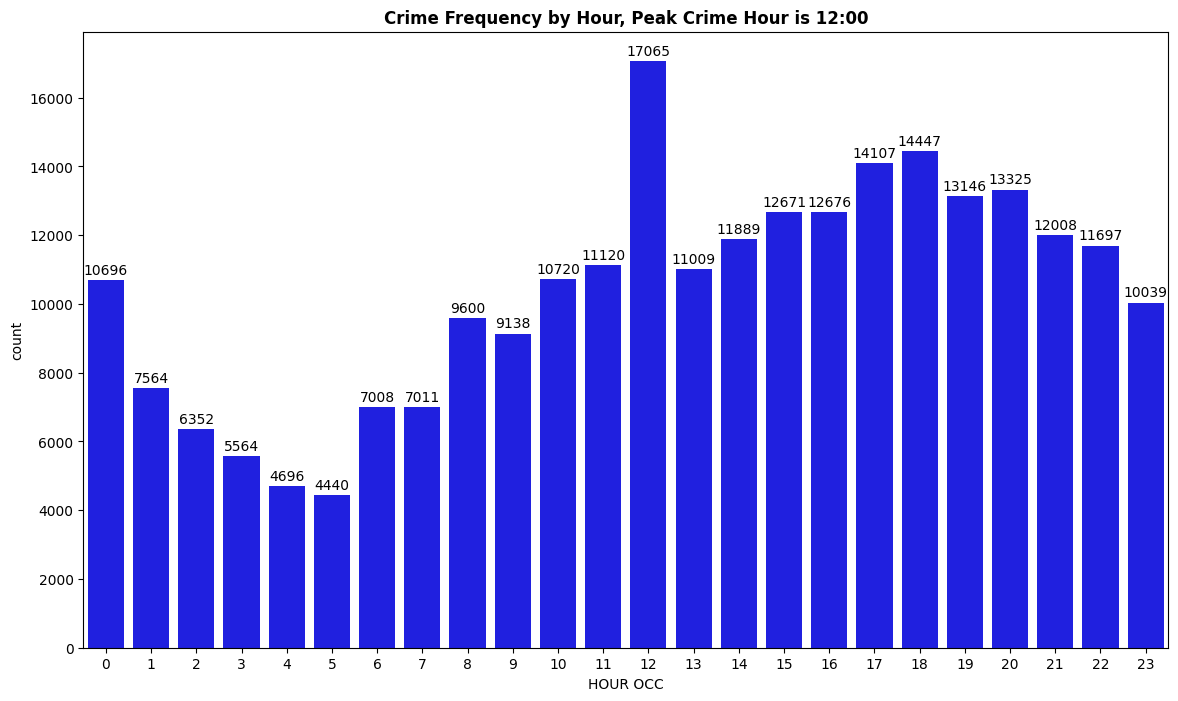

In [40]:
plt.figure(figsize=(14, 8))
ax= sns.countplot(data=project, x='HOUR OCC', color= 'blue')
ax.bar_label(ax.containers[0],padding= 2)
plt.title(f'Crime Frequency by Hour, Peak Crime Hour is {peak_crime_hour}:00',fontweight='bold')
plt.show()

In [20]:
#Q2
nightHours=[22,23,0,1,2,3]
nightCrimes=project[project['HOUR OCC'].isin(nightHours)]
peak_night_crime_area = nightCrimes['AREA NAME'].mode()[0]
print( f'The area with the highest frequency of night crimes is: {peak_night_crime_area}')

The area with the highest frequency of night crimes is: Central


In [21]:
nightCrimes.head(5)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION,HOUR OCC
9,231207476,2023-02-27,2020-08-15,1,77th Street,BURGLARY,72,Male,B,Unknown,Invest Cont,8800 HAAS AV,0
12,221711184,2022-06-15,2020-05-15,155,Devonshire,THEFT OF IDENTITY,27,Male,B,Unknown,Invest Cont,8300 WHITE OAK AV,1
36,221314362,2022-07-11,2020-04-07,1,Newton,THEFT OF IDENTITY,53,Female,H,Unknown,Invest Cont,1600 E OLYMPIC BL,0
39,231307252,2023-03-03,2020-07-05,2305,Newton,THEFT OF IDENTITY,22,Female,B,Unknown,Invest Cont,6600 S BROADWAY,23
42,221614254,2022-11-13,2020-01-01,1,Foothill,THEFT OF IDENTITY,22,Female,H,Unknown,Invest Cont,10200 TELFAIR AV,0


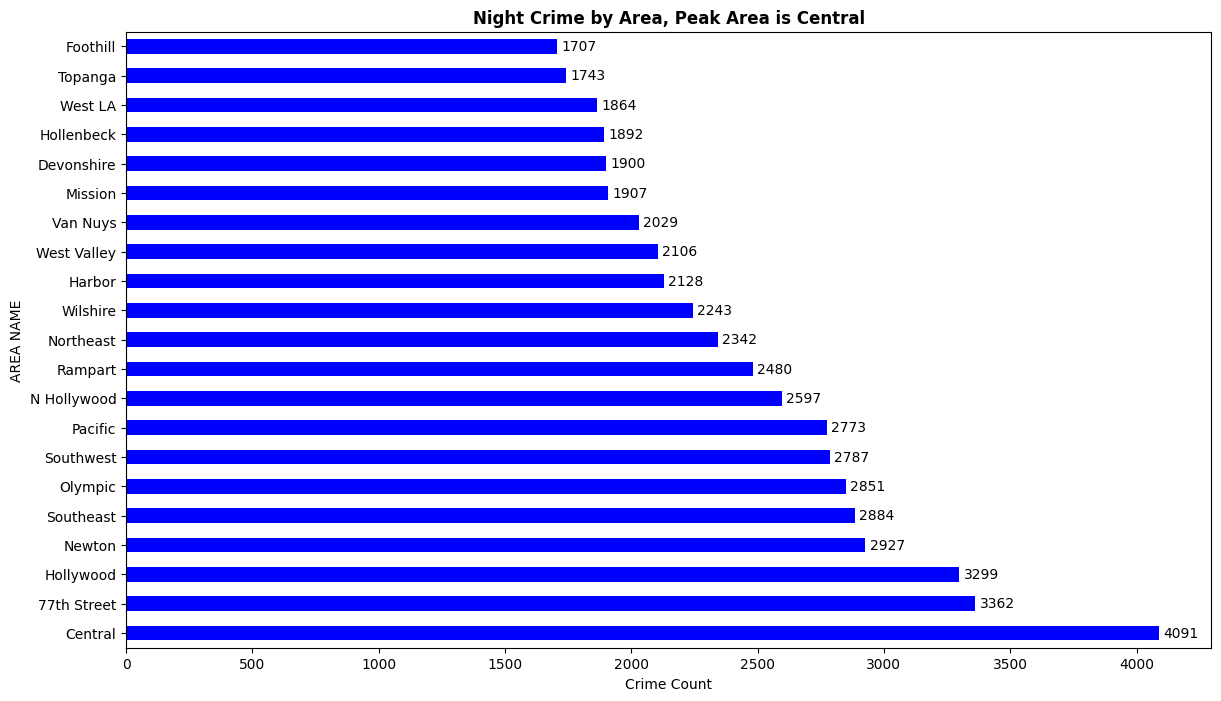

In [36]:
plt.figure(figsize=(14, 8))
ax= nightCrimes['AREA NAME'].value_counts().plot(kind='barh', color='blue')
ax.bar_label(ax.containers[0],padding =3)
plt.title(f'Night Crime by Area, Peak Area is {peak_night_crime_area}',fontweight='bold')
plt.xlabel('Crime Count')
plt.show()

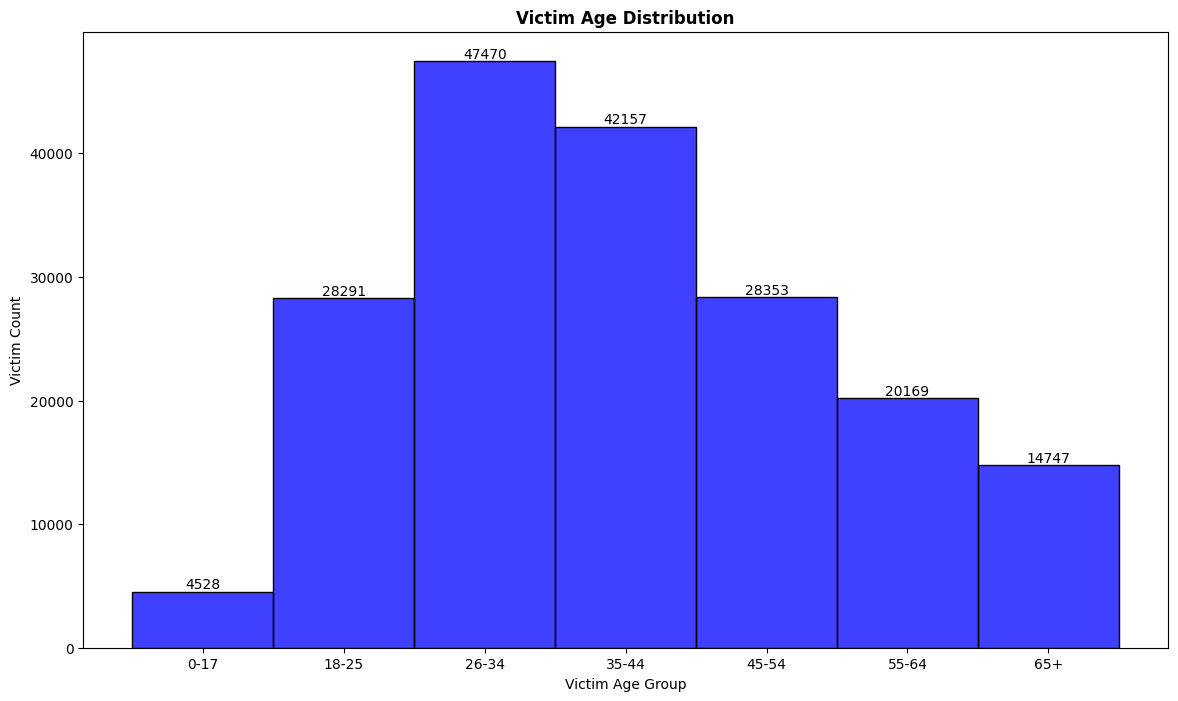

Age Bracket
0-17      4528
18-25    28291
26-34    47470
35-44    42157
45-54    28353
55-64    20169
65+      14747
Name: count, dtype: int64


In [37]:
#Q3
ageBins = [0, 17, 25, 34, 44, 54, 64, np.inf]
ageLabels = ['0-17','18-25','26-34','35-44','45-54','55-64','65+']

validAge = project[project['Vict Age'] > 0].copy()

validAge['Age Bracket'] = pd.cut( validAge['Vict Age'], bins=ageBins,labels=ageLabels)

plt.figure(figsize=(14, 8))
ax = sns.histplot( data=validAge,x='Age Bracket',color='blue',)

ax.bar_label(ax.containers[0])

plt.title('Victim Age Distribution', fontweight='bold')
plt.xlabel('Victim Age Group')
plt.ylabel('Victim Count')

plt.show()

victim_ages = validAge['Age Bracket'].value_counts().sort_index()
print (victim_ages)


Lower Bound: -5.0 years | Upper Bound: 83.0 years
Total Outliers Found: 1,218
Outlier Age Range: 84 to 99 years


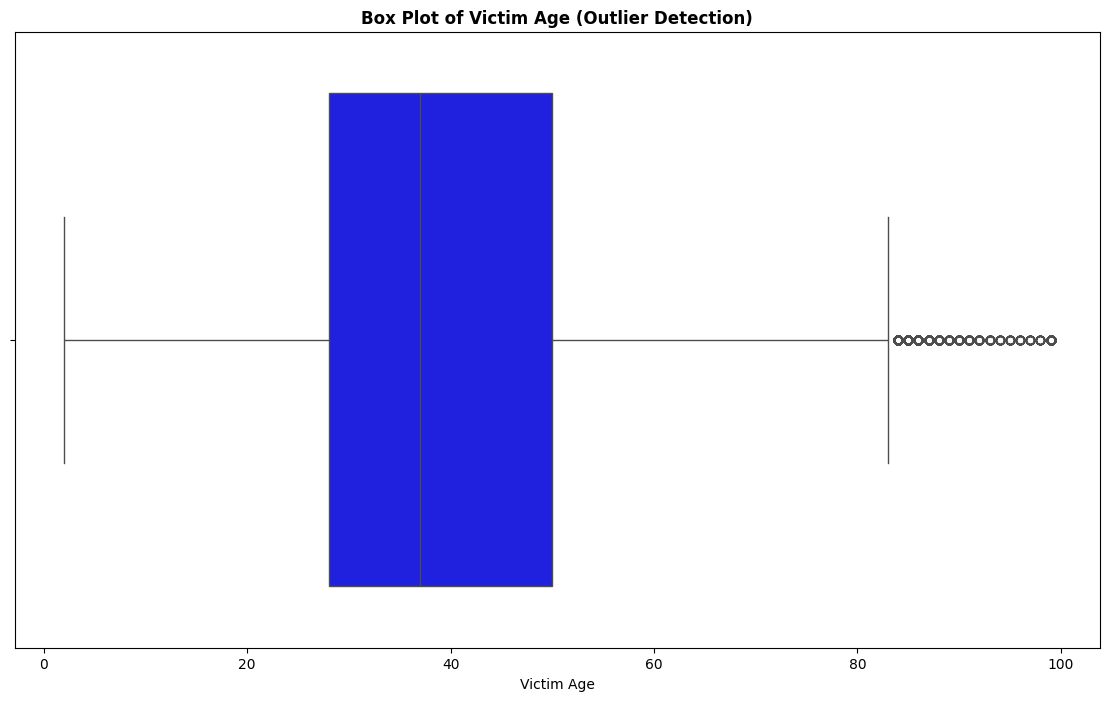

In [38]:
#Q4
q1= validAge['Vict Age'].quantile (0.25)
q3= validAge['Vict Age'].quantile(0.75)
iqr=q3-q1
lower=q1-(iqr*1.5)
upper=q3+(iqr*1.5)

outliers=validAge[(validAge['Vict Age']<lower) | (validAge['Vict Age']>upper)]
print(f'Lower Bound: {lower:.1f} years | Upper Bound: {upper:.1f} years')
print(f'Total Outliers Found: {len(outliers):,}')
print(f'Outlier Age Range: {outliers["Vict Age"].min()} to {outliers["Vict Age"].max()} years')

plt.figure(figsize=(14, 8))
sns.boxplot(x=validAge['Vict Age'], color='blue')
plt.title('Box Plot of Victim Age (Outlier Detection)', fontweight='bold')
plt.xlabel('Victim Age')
plt.show()

Saving the file

In [27]:
project['Age Bracket'] = pd.cut( project['Vict Age'], bins=ageBins, labels=ageLabels)
project['Age Bracket'] = (project['Age Bracket'].astype(str).replace({'nan': 'Unknown'}))

In [29]:
project.head(3)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION,HOUR OCC,Age Bracket
0,221412410,2022-06-15,2020-11-12,1700,Pacific,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),0,Unknown,Unknown,Unknown,Invest Cont,13600 MARINA POINT DR,17,Unknown
1,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,Female,B,Unknown,Invest Cont,2500 S SYCAMORE AV,11,26-34
2,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,Male,H,Unknown,Invest Cont,3300 SAN MARINO ST,16,55-64


In [34]:
project.to_csv("/content/crimes_clean.csv")